/Users/hongohayato/Desktop/labelme/labelme-env/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


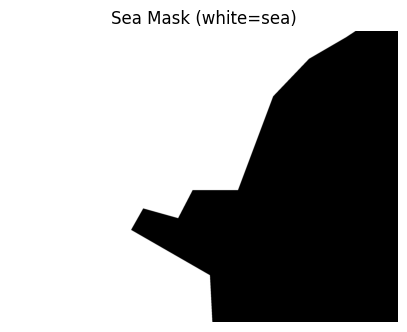

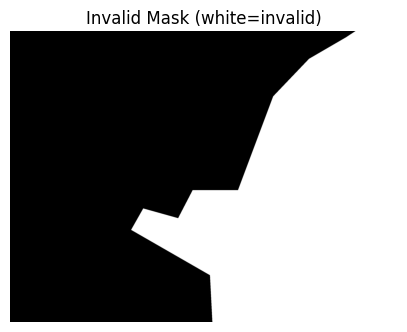

/var/folders/jt/5_z36q1n1sg3hfdfbkzytlyh0000gn/T/ipykernel_33579/2558074576.py:86: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, 1)


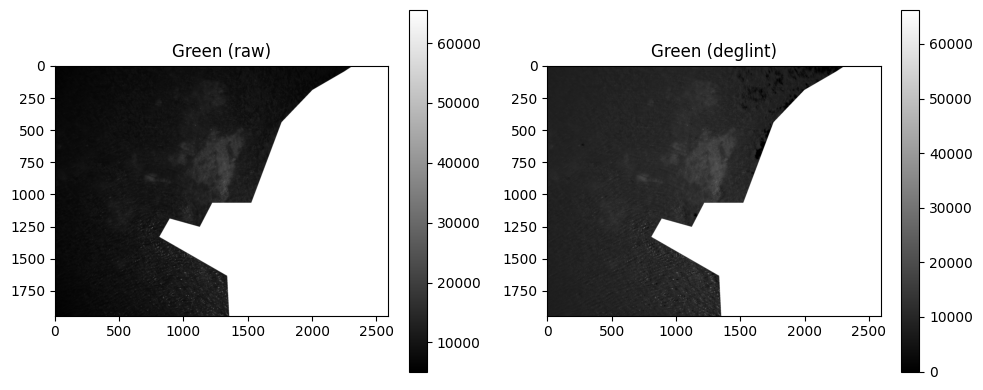

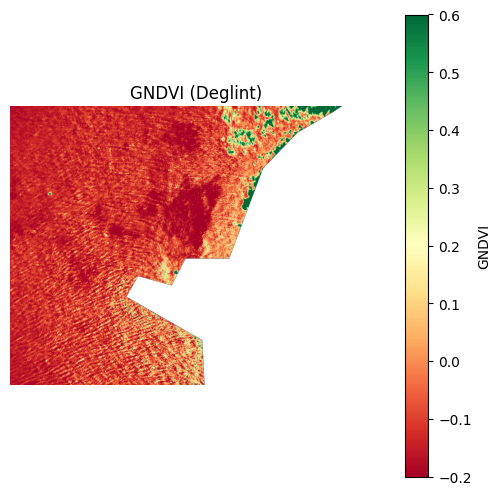

In [ ]:
import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# ===== 1. ファイルパス =====
base_path = "test/DJI_20260409131611_0029"
g_path   = base_path + "_MS_G.TIF"
r_path   = base_path + "_MS_R.TIF"
re_path  = base_path + "_MS_RE.TIF"
nir_path = base_path + "_MS_NIR.TIF"

json_path = base_path + "_MS_G.json"

jpg_path = base_path + "_D.JPG"

# ===== 2. 読み込み =====
def read_tif(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32)

Green = read_tif(g_path)
Red   = read_tif(r_path)
RE    = read_tif(re_path)
NIR   = read_tif(nir_path)

H, W = Green.shape

# ===== 3. JSON → 海マスク =====
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

w = data["imageWidth"]
h = data["imageHeight"]

# サイズチェック（重要）
assert (H, W) == (h, w), f"サイズ不一致: image=({H},{W}), json=({h},{w})"

land_mask = Image.new("L", (w, h), 0)
draw = ImageDraw.Draw(land_mask)

for shape in data["shapes"]:
    points = [tuple(p) for p in shape["points"]]
    draw.polygon(points, fill=255)

# 海マスク（True=海）
sea_mask = np.array(land_mask) == 0

# ===== 4. 可視化（マスク確認）=====
plt.figure(figsize=(5,5))
plt.imshow(sea_mask, cmap='gray')
plt.title("Sea Mask (white=sea)")
plt.axis('off')
plt.show()

# ===== 5. NoData判定 =====
nodata = 65535

nodata_mask = (
    (Green == nodata) |
    (Red   == nodata) |
    (RE    == nodata) |
    (NIR   == nodata)
)

invalid = nodata_mask | (~sea_mask)

# ===== 6. invalid可視化 =====
plt.figure(figsize=(5,5))
plt.imshow(invalid, cmap='gray')
plt.title("Invalid Mask (white=invalid)")
plt.axis('off')
plt.show()

# ===== 7. NaN適用 =====
for band in [Green, Red, RE, NIR]:
    band[invalid] = np.nan

# ===== 8. サングリント除去 =====
Rnir_mean = np.nanmean(NIR)

def calc_k(NIR, band):
    mask = np.isfinite(NIR) & np.isfinite(band)
    x = NIR[mask]
    y = band[mask]
    p = np.polyfit(x, y, 1)
    return p[0]

k_g = calc_k(NIR, Green)

Green_corr = Green - k_g * (NIR - Rnir_mean)
Green_corr[Green_corr < 0] = 0

# ===== 9. 補正確認 =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(Green, cmap='gray')
plt.title("Green (raw)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(Green_corr, cmap='gray')
plt.title("Green (deglint)")
plt.colorbar()

plt.tight_layout()
plt.show()

# ===== 10. GNDVI =====
GNDVI = np.full_like(NIR, np.nan)

valid = (
    np.isfinite(NIR) &
    np.isfinite(Green_corr) &
    ((NIR + Green_corr) != 0)
)

GNDVI[valid] = (NIR[valid] - Green_corr[valid]) / (NIR[valid] + Green_corr[valid])

# ===== 11. GNDVI可視化 =====
plt.figure(figsize=(6,6))
plt.imshow(GNDVI, cmap='RdYlGn', vmin=-0.2, vmax=0.6)
plt.colorbar(label="GNDVI")
plt.title("GNDVI (Deglint)")
plt.axis('off')
plt.show()

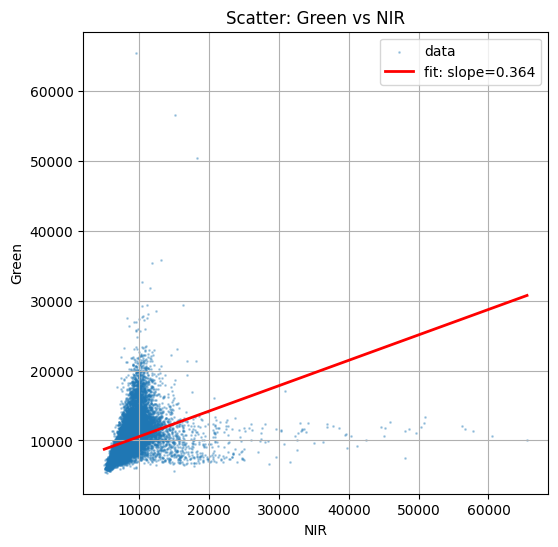

In [2]:
# ===== 散布図（Green vs NIR）=====
mask = np.isfinite(NIR) & np.isfinite(Green)

x = NIR[mask]
y = Green[mask]

# データ多すぎるので間引き（重要）
n = len(x)
idx = np.random.choice(n, size=min(20000, n), replace=False)
x_s = x[idx]
y_s = y[idx]

# 回帰直線
p = np.polyfit(x_s, y_s, 1)
x_line = np.linspace(x_s.min(), x_s.max(), 100)
y_line = p[0] * x_line + p[1]

plt.figure(figsize=(6,6))
plt.scatter(x_s, y_s, s=1, alpha=0.3, label="data")
plt.plot(x_line, y_line, 'r', linewidth=2, label=f"fit: slope={p[0]:.3f}")

plt.xlabel("NIR")
plt.ylabel("Green")
plt.title("Scatter: Green vs NIR")
plt.legend()
plt.grid(True)

plt.show()

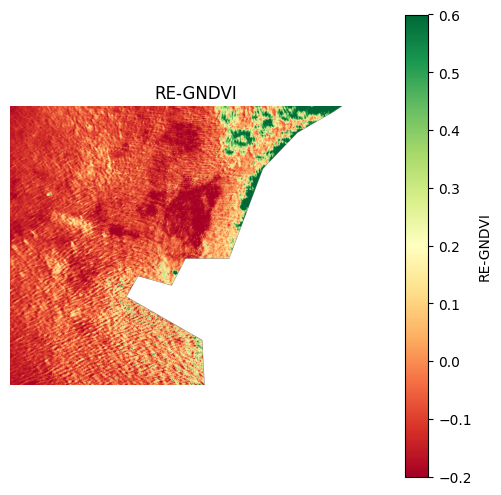

In [3]:
# ===== RE-GNDVI =====
RE_GNDVI = np.full_like(RE, np.nan)

valid = (
    np.isfinite(RE) &
    np.isfinite(Green_corr) &
    ((RE + Green_corr) != 0)
)

RE_GNDVI[valid] = (RE[valid] - Green_corr[valid]) / (RE[valid] + Green_corr[valid])

plt.figure(figsize=(6,6))
plt.imshow(RE_GNDVI, cmap='RdYlGn', vmin=-0.2, vmax=0.6)
plt.colorbar(label="RE-GNDVI")
plt.title("RE-GNDVI")
plt.axis('off')
plt.show()

Original dtype: float32


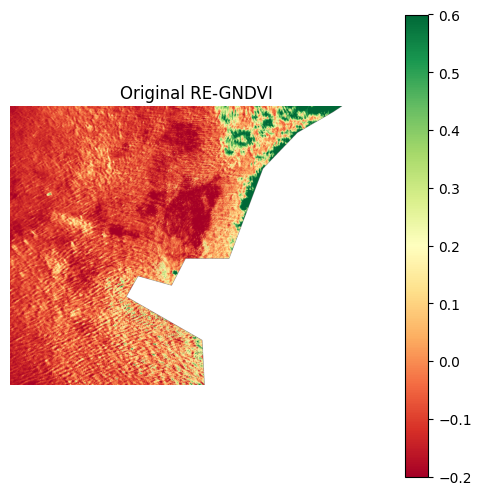

Normalized dtype: float32


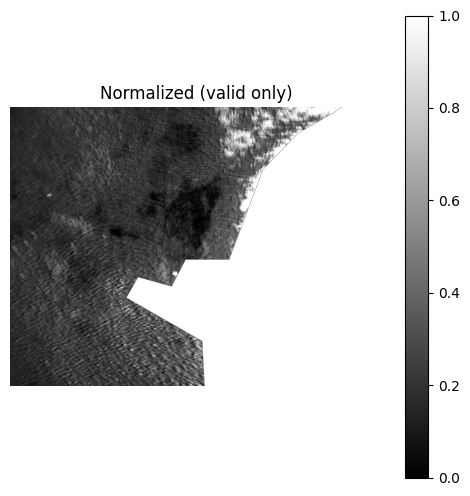

CLAHE dtype: float32


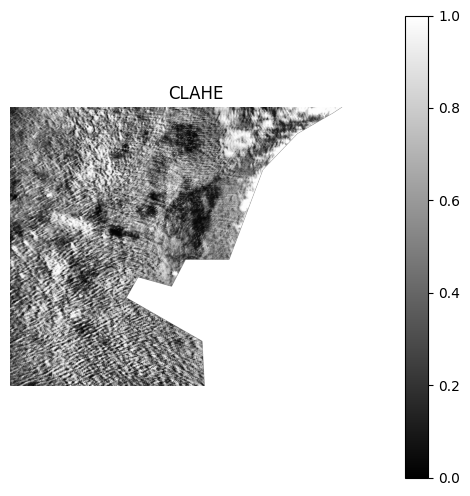

Gaussian dtype: float64


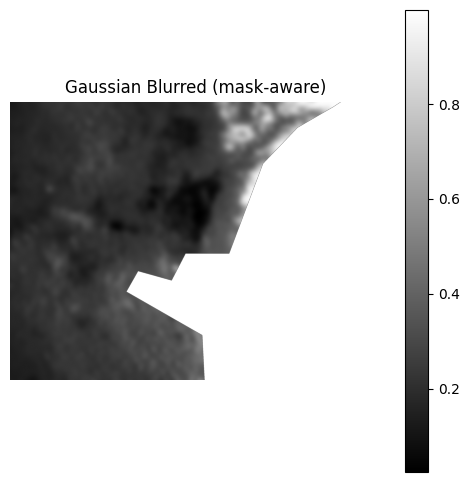

Final dtype: float64


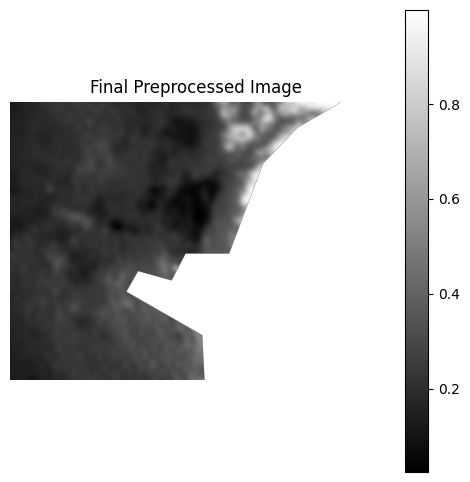

In [4]:
from skimage import exposure
from skimage.filters import gaussian
from skimage.util import img_as_float
import numpy as np
import matplotlib.pyplot as plt

# ===== 0. 有効マスク =====
valid_mask = np.isfinite(RE_GNDVI) & sea_mask & (~nodata_mask)

# ===== 1. 元画像確認 =====
print("Original dtype:", RE_GNDVI.dtype)

plt.figure(figsize=(6,6))
plt.imshow(RE_GNDVI, cmap='RdYlGn', vmin=-0.2, vmax=0.6)
plt.title("Original RE-GNDVI")
plt.colorbar()
plt.axis('off')
plt.show()

# ===== 2. 正規化（validだけでスケーリング）=====
vmin, vmax = np.nanpercentile(RE_GNDVI[valid_mask], (1, 99))

image = np.zeros_like(RE_GNDVI, dtype=np.float32)
image[valid_mask] = (RE_GNDVI[valid_mask] - vmin) / (vmax - vmin)
image = np.clip(image, 0, 1)

print("Normalized dtype:", image.dtype)

plt.figure(figsize=(6,6))
plt.imshow(np.ma.masked_where(~valid_mask, image), cmap='gray')
plt.title("Normalized (valid only)")
plt.colorbar()
plt.axis('off')
plt.show()


# ===== 3. CLAHE =====
clip_limit = 0.03
clahe_image = exposure.equalize_adapthist(image, clip_limit=clip_limit)

# 無効領域を戻す
clahe_image[~valid_mask] = 0

print("CLAHE dtype:", clahe_image.dtype)

plt.figure(figsize=(6,6))
plt.imshow(np.ma.masked_where(~valid_mask, clahe_image), cmap='gray')
plt.title("CLAHE")
plt.colorbar()
plt.axis('off')
plt.show()

# ===== 4. Gaussian（にじみ対策版）=====

gaussian_sigma = 20

# --- 方法：マスク補正付きGaussian ---
# 重み付きでにじみを防ぐ（重要）
weight = valid_mask.astype(float)

blurred_num = gaussian(image * weight, sigma=gaussian_sigma)
blurred_den = gaussian(weight, sigma=gaussian_sigma)

# 0割防止
with np.errstate(invalid='ignore'):
    clahe_blurred_image = blurred_num / blurred_den

# 無効領域はNaNに戻す
clahe_blurred_image[~valid_mask] = np.nan

print("Gaussian dtype:", clahe_blurred_image.dtype)

plt.figure(figsize=(6,6))
plt.imshow(np.ma.masked_invalid(clahe_blurred_image), cmap='gray')
plt.title("Gaussian Blurred (mask-aware)")
plt.colorbar()
plt.axis('off')
plt.show()

# ===== 5. float変換 =====
preprocessed_image = img_as_float(clahe_blurred_image)
preprocessed_image[~valid_mask] = np.nan

print("Final dtype:", preprocessed_image.dtype)

plt.figure(figsize=(6,6))
plt.imshow(np.ma.masked_invalid(preprocessed_image), cmap='gray')
plt.title("Final Preprocessed Image")
plt.colorbar()
plt.axis('off')
plt.show()

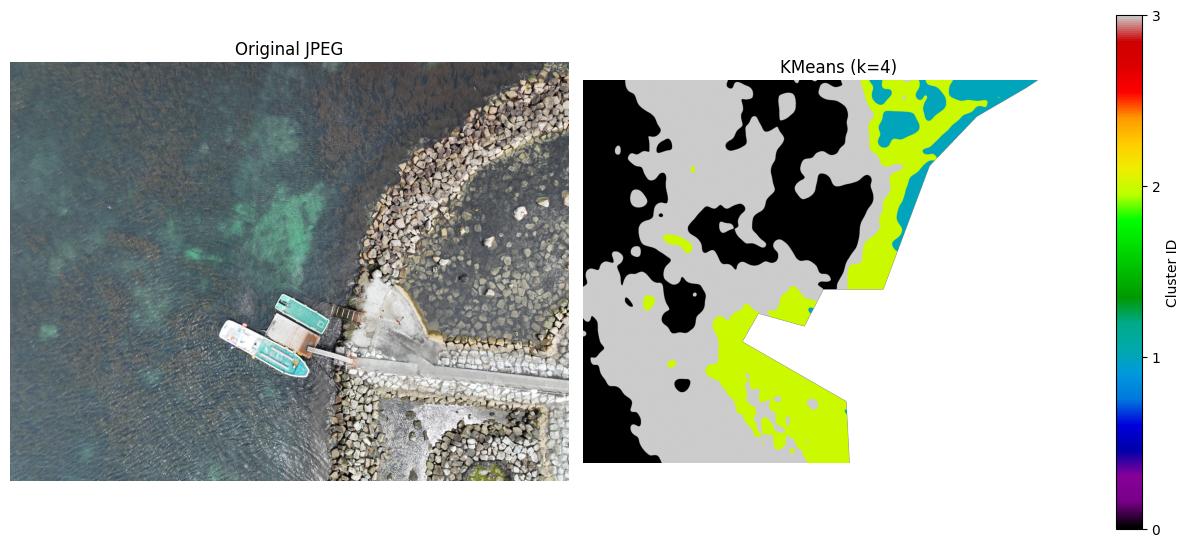

In [5]:
from sklearn.cluster import KMeans

# ===== 1. reshape =====
h, w = preprocessed_image.shape
pixels = preprocessed_image.reshape(-1, 1)

# ===== 2. NaN除外 =====
valid = np.isfinite(pixels[:, 0])
pixels_valid = pixels[valid]

# ===== 3. KMeans =====
k = 4
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)

labels = np.full(pixels.shape[0], np.nan)
labels[valid] = kmeans.fit_predict(pixels_valid)

# ===== 4. reshape =====
segmented = labels.reshape(h, w)

# ===== 5. 可視化（元JPEG + クラスタ結果を横並び） =====
from PIL import Image
jpg_img = Image.open(jpg_path).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 左：オリジナルJPEG（マスクなし）
axes[0].imshow(jpg_img)
axes[0].set_title("Original JPEG")
axes[0].axis("off")

# 右：クラスタ結果（NaNは透明）
seg_masked = np.ma.masked_invalid(segmented)
im1 = axes[1].imshow(seg_masked, cmap="nipy_spectral", vmin=0, vmax=k - 1)
axes[1].set_title(f"KMeans (k={k})")
axes[1].axis("off")
cbar = fig.colorbar(im1, ax=axes[1], ticks=np.arange(k), fraction=0.046, pad=0.04)
cbar.set_label("Cluster ID")

plt.tight_layout()
plt.show()

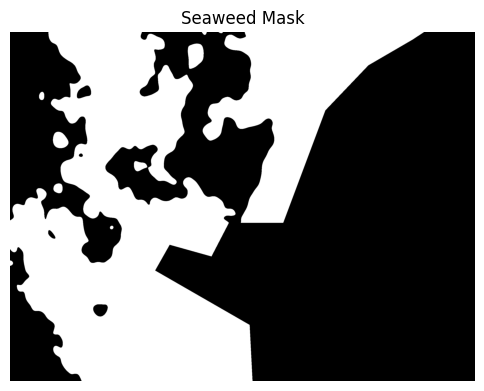

In [7]:
# 例：藻場「でない」と判断したクラスタ
non_seaweed_clusters = [0]  # ←ここを手で決める（藻場以外）

# 藻場マスク（True=藻場）
seaweed_mask = np.isfinite(segmented) & (~np.isin(segmented, non_seaweed_clusters))

plt.figure(figsize=(6,6))
plt.imshow(seaweed_mask, cmap='gray')
plt.title("Seaweed Mask")
plt.axis('off')
plt.show()

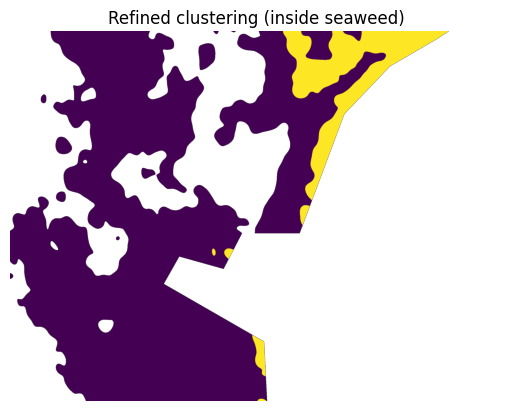

In [9]:
# 藻場だけ抽出
X2 = preprocessed_image[seaweed_mask]

# reshape
X2 = X2.reshape(-1, 1)

# 再クラスタ
k2 = 2
kmeans2 = KMeans(n_clusters=k2, random_state=0, n_init=10)

labels2 = kmeans2.fit_predict(X2)

# 元画像サイズに戻す
refined = np.full_like(preprocessed_image, np.nan)
refined[seaweed_mask] = labels2

plt.imshow(refined, cmap='viridis')
plt.title("Refined clustering (inside seaweed)")
plt.axis('off')
plt.show()

In [8]:
X = GNDVI.flatten()
valid = np.isfinite(X)
Xv = X[valid]

In [9]:
from sklearn.cluster import KMeans

K = 5  # とりあえず（あとで調整）
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

labels = np.full_like(X, np.nan)
labels[valid] = kmeans.fit_predict(Xv)

clustered_img = labels.reshape(GNDVI.shape)

ValueError: Expected 2D array, got 1D array instead:
array=[-0.22475582 -0.2618413  -0.2056379  ... -0.16162786 -0.03111093
 -0.0952915 ].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.